# Chronos age fitter tutorial

This notebook serves as a quick tutorial of how to use the `ChronosSkewCauchyBayes` function of `CHRONOS`.

#### Chronos imports

In [1]:
from chronos.utils import ExtinctionPrior
from chronos.utils.utils import mode_reals
from chronos.bayes_fitting import ChronosSkewCauchyBayes

#### Gerneral imports

In [2]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

## 1. Load dataset

Here we load an example dataset (Sco-Cen clusters from Ratzenboeck et al, 2023a,b) from the Tutorials/data/ folder and select a random cluster.

In [3]:
cluster_name = "eta Cham"

df_all = pd.read_csv("data/sco-cen_clusters.csv")
df_group = df_all[df_all.Group == cluster_name]

print(f"The chosen cluster is: {cluster_name}\nThis cluster has {len(df_group)} member stars.")

The chosen cluster is: eta Cham
This cluster has 30 member stars.


## 2. *Optionals
### 2.1. Standardize column names

The code is expecting standard Gaia DR3 column names (TAP). There is a mapping implemented in `utils.utils.column_mapping` but otherwise you will have to define your own mapping.

In [4]:
from chronos.utils import rename_vizier_to_tap

In [5]:
df_group = rename_vizier_to_tap(df_group)

### 2.2. Perform quality cuts

The ones in this example are taken from Ratzenboeck et al, 2023b.

First, we need to add the columns to the dataframe.

In [6]:
df_group.loc[:,'G_err'] = 1.0857 / df_group['phot_g_mean_flux_over_error']
df_group.loc[:, 'G_RPerr'] = 1.0857 / df_group['phot_rp_mean_flux_over_error']
df_group.loc[:,'G_BPerr'] = 1.0857 / df_group['phot_bp_mean_flux_over_error']

Define the mask for the dataframe, including all your desired quality cuts and use it to divide the dataframe into "good" and "bad" CMD stars.

In [7]:
cut_age = (
            (df_group["G_err"] < 0.007) &
            (df_group["G_RPerr"] < 0.03) &
            (df_group["G_BPerr"] < 0.15)
    )

In [8]:
df_age = df_group[cut_age]
df_not_age = df_group[~cut_age]

print(f"After applying the above quality cuts we have:\n{len(df_age)} good stars ({round(len(df_age)/len(df_group)*100,1)}%)\n{len(df_not_age)} bad stars")

After applying the above quality cuts we have:
27 good stars (90.0%)
3 bad stars


### 2.3. Sample extinction prior from the dust map

**ATTENTION: To do this step, you need to have the dustmap of Edenhofer et al, 2023 available locally.**

If so, place it into the data directory at: `src/chronos/data/` or change the data path to where-ever the file is located on your machine.

In [9]:
from chronos import DATA_DIR

fname_ext = DATA_DIR / "dustmap_edenhofer/edenhofer_2023/mean_and_std_healpix.fits"
ext = ExtinctionPrior(fname_ext)

Integrating extinction map (this might take a couple of minutes)...
Optimizing map for querying (this might take a couple of seconds)...


Plot a histogram of the sampled extinction range together with the 1., 50., and 99. percentile to get a feeling for the prior range.

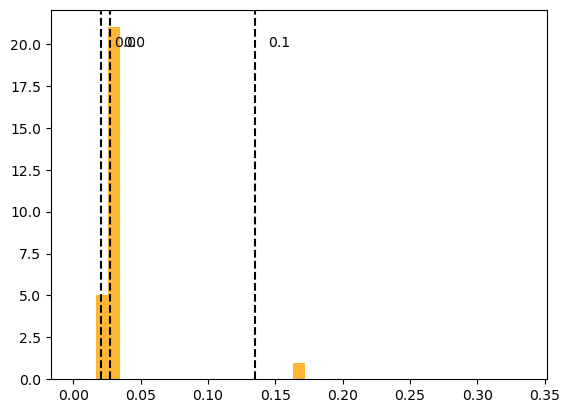

In [10]:
# This is to get a feeling of the Av distribution
extinction_prior = ext.compute_prior(df_age['ra'], df_age['dec'], plx=df_age['parallax'])
av_r = np.max([0, np.nanpercentile(extinction_prior, 1) - 0.1]), np.nanpercentile(extinction_prior, 99) + 0.2
av_fig, ax = plt.subplots(1,1)
hist = ax.hist(extinction_prior, bins=np.linspace(*av_r, 40), alpha=0.8, color="orange")
ylims = ax.get_ylim()

for perc in np.nanpercentile(extinction_prior, [1, 50, 99]):
    plt.axvline(perc, c='k', ls='--')
    plt.text(x=perc+0.01, y = ylims[1]*(1-0.1), s=f'{perc:.1f}')

plt.show()

## 3. Fitting the cluster age

### 3.1. Initialize the fitter

In [11]:
cbayes = ChronosSkewCauchyBayes(
        data=df_age,
        use_grp=False,                  # if True, uses the G-RP color magnitude CMD, default is BP-RP
        models='parsec',                # other implementations are 'baraffe' and 'dartmouth'
    )

PARSEC isochrones read and processed!


### 3.2. Define the priors

In [12]:
def get_av_range_from_dustmap(av_prior, low_percentile, high_percentile, offset):
    return np.max(
    [0, np.nanpercentile(av_prior, low_percentile) - offset]), \
    np.nanpercentile(av_prior, high_percentile) + offset


#### Physical priors

In [13]:
age_low, age_high = 1, 200                                          # age limits in Myr
logAge_range = np.log10(age_low * 10 ** 6), np.log10(age_high * 10 ** 6)    # transform to log_age because this is the required format
av_range = get_av_range_from_dustmap(av_prior=extinction_prior,
                                     low_percentile=5,              # this computes the A_v range from the dustmap prior
                                     high_percentile=95,            # but it can also be just given manually if you do not
                                     offset=0.1,                    # want to include sampling the dustmap as a step
                                     )
metallicity_range = (-1e-3, 1e-3)

#### Fitting-specific priors

- The `ChronosSkewCauchyBayes` uses a skewed Cauchy distribution as base function, when calculating the distance between a given datapoint and the model isochrone that is currently being fitted. The exact shape of this distribution can be controlled via the `skewness_range`. Sebastian has some tried and tested values, but in my own experience, especially when one fits *young clusters* with some scatter away from the ZAMS due to reddening etc, I feel like setting the range quite broad yields good results.
    <br>
- The distance of a star "above" the isochrone, e.g., young stars or unresolved binaries, can be taken into account using `scale_range`. Again, Sebastian has some tested values, but I leave this quite broad.
    <br>
- Lastly, the `fit_range` describes the dynamical range of (typically G-Band) absolute magnitudes that is taken into account in the fitting. Usually, the bright end is left open but at the faint end, a cut-off around 10 to 12 mag makes sense, depending on the used isochrone and use case, as the model isochrones are known to diverge from the data significantly beyond these values.

In [14]:
skewness_range = (0.0, 0.99)
scale_range = (0.01, 0.5)
fit_range=(-np.inf, 10)

### 3.3. Define the Bayes bounds based on the prior

This section just puts the pre-defined ranges into a dictionary and feeds this into the fitter-object.

In [15]:
bayes_bounds = dict(
        logAge_range=logAge_range,
        av_range=av_range,
        feh_range=metallicity_range,
        skewness_range= skewness_range,
        scale_range= scale_range,

    )

cbayes.set_fitting_kwargs(**bayes_bounds,
                          fit_range=fit_range,
                          do_mass_normalize=False,
                          weights=None)

cbayes.set_bounds(**bayes_bounds)

### 3.4. Running the fitter

The fitter is run with the following command, and uses MCMC sampling internally. Be aware that this can make things a bit slow (some minutes to almost an hour for thousands of sources) in case of large cluster sizes. You can adjust the number of walkers and burnin steps as needed (I never explored them).

In [16]:
sampler, best_fit, samples_bprp = cbayes.fit_bayesian(nwalkers=80, nsteps=800, burnin=150)

Next, we sample the posteriors to be able to judge the "goodness" of our fit.

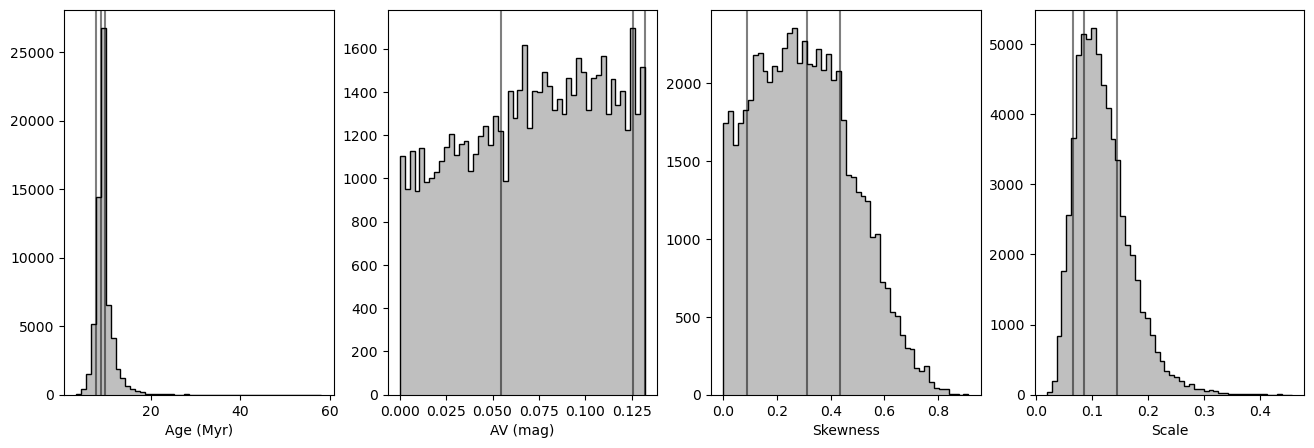

In [17]:
logAge, feh, A_V, skewness, scale = samples_bprp.T
to_plot = 10 ** logAge / 10 ** 6, A_V, skewness, scale
names = 'Age (Myr)', 'AV (mag)', 'Skewness', 'Scale'
fig, axes = plt.subplots(1, len(names), figsize=(len(names) * 4, 5))

for name, data2plot, ax in zip(names, to_plot, axes):
    ax.hist(data2plot, bins=50, histtype='step', color='k')
    ax.hist(data2plot, bins=50, histtype='stepfilled', color='k', alpha=0.25)
    mode_hist = mode_reals(data2plot, bins=100)
    lo, hi = az.hdi(data2plot, hdi_prob=0.64)
    for al in [mode_hist, lo, hi]:
        ax.axvline(al, c='k', alpha=0.5)
    ax.set_xlabel(name)
plt.show()

# 4. Inspecting the results

We can grab the all fit parameters directly from the fit.

### 4.1. Ages

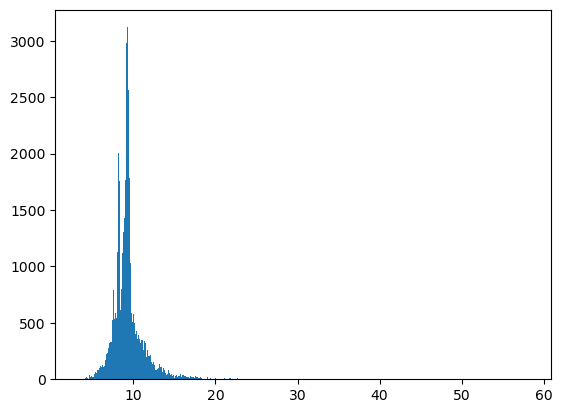

In [18]:
ages_myr = 10 ** logAge / 10 ** 6
age_mode = mode_reals(ages_myr, bins=100)
age_low, age_high = az.hdi(ages_myr, hdi_prob=0.64)

fig = plt.figure()
plt.hist(ages_myr,bins="auto")

plt.show()

### 4.2. Extinction

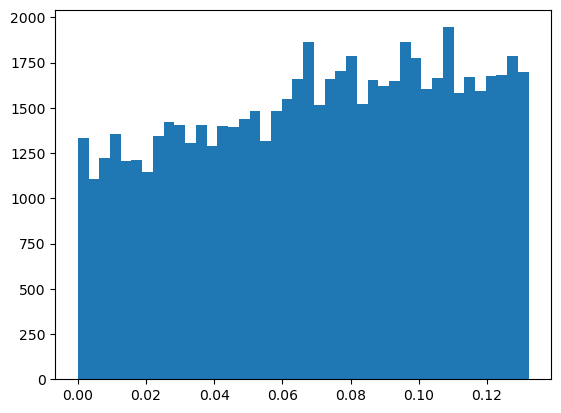

In [19]:
av_mode = mode_reals(A_V, bins=100)
av_low, av_high = az.hdi(A_V, hdi_prob=0.64)

fig = plt.figure()
plt.hist(A_V,bins="auto")

plt.show()

### 4.3. Masses

**Disclaimer**: I have never used these myself.

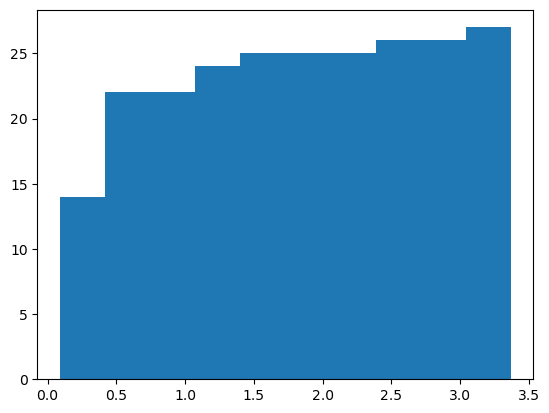

In [20]:
dist_total, masses, keep2fit = cbayes.compute_fit_info(
    logAge=np.log10(age_mode * 10 ** 6), feh=0, A_V=av_mode, g_rp=cbayes.use_grp, signed_distance=True
)

fig = plt.figure()
plt.hist(masses,bins="auto", cumulative=True)

plt.show()

In [21]:
print(f"Confirmation: Masses computed for every star: {len(masses) == len(df_age)}")

Confirmation: Masses computed for every star: True


### 4.4. Plot the CMD

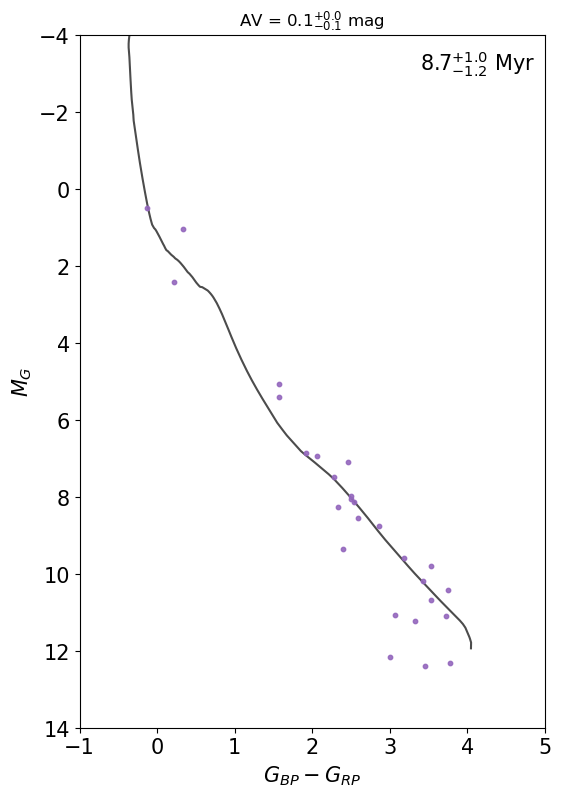

In [22]:
size = 15
hrd = plt.figure(figsize=(6, 9))
plt.scatter(*cbayes.distance_handler.fit_data['hrd'].T, s=10, c='tab:purple', edgecolors='tab:purple',
            alpha=0.9)
plt.ylim(14, -4)
plt.xlim(-1, 5)
plt.xlabel(r'$G_{BP} - G_{RP}$', size=size)
plt.ylabel(r'$M_G$', size=size)
plt.xticks(size=size)
plt.yticks(size=size)

# Plot isochrone
isochrone = cbayes.isochrone_handler.model(logAge=np.log10(age_mode * 10 ** 6), feh=0, A_V=av_mode,
                                           g_rp=cbayes.use_grp)
plt.plot(*isochrone.T, label=r'${{{:.1f}}}$ Myr'.format(age_mode),
         c='k', alpha=0.7, zorder=0)
plt.title(
    r'AV = ${{{:.1f}}}^{{+{:.1f}}}_{{{:.1f}}}$ mag'.format(av_mode, av_high - av_mode, av_low - av_mode, size=size))
plt.annotate(r'${{{:.1f}}}^{{+{:.1f}}}_{{{:.1f}}}$ Myr'.format(age_mode, age_high - age_mode, age_low - age_mode),
             (0.98, 0.98), xycoords='axes fraction', ha='right', va='top', size=size)

plt.show()